# The Objective
The objective of this file is to explore and develop a small and powerful model which can be easily transfered over the internet for inference on the local device.
Hence, to achieve different relations between images, text and other file format is being explored for the development of the model.


## Tasks at hand
1. Add a layer of attention before the lstm layer to make better corelations between different words.
2. Add a variance study to the model result.
3. Study R^2 and R^2 adjusted to get if the model is good or not.
4. find if you can study parameters using index values or do i need logits passed though sigmoid i.e. probability.


## Important:
1. Quants use ML to filter the stocks with best possible results from a given bunch. This gets them the estimate of the best possible stocks.
2. Study the Wave Field LLM
3. Study Non Linear time series data with noise
4. Analysis in R

## Specification of system used:
1. CPU              : AMD EPYC 7742 64-Core Processor
2. GPU              : Nvidia A100
3. No. of GPU used  : 1
4. RAM              : 2TB
5. VRAM             : 80GB
6. CUDA driver      : 535.230.02
7. CUDA version     : 12.8
8. Container        : Nvidia JAX 25.01-py3

## Necessary imports
1.  pandas [2.2.3]     : to manipulate the dataset for analysis and data extraction
2.  flax   [0.10.2]    : to create the model with training and testing.
3.  Optax  [0.2.4]     : to get an optimizer for the training of the model
4.  spacy  [3.8.11]    : to convert the obtained dataset into embeddings and tokens
5.  conllu [6.0.0]     : to handle the parsing of the given sentences
6.  jax    [0.4.38.dev20250115+838500378]     : to handle computing and array tasks
7.  tqdm   [4.67.3]    : to show loading bar for the tasks
8.  numpy  [2.2.2]     : to handle the array based tasks

In [39]:
#necessary imports
# '%' is jupyter safe when installing on local environment in jupyter lab
try:
    import pandas as pd
    from flax import nnx
    from conllu import parse
    import spacy, optax
    import numpy as np
    import jax.numpy as jnp
    from tqdm import tqdm
    import evaluate 
    import nltk
    import jax
except ImportError or ModuleNotFoundError:
    print('Required Libraries not found. Installing Now...\n')
    %pip install jax[cuda12]
    %pip install conllu
    %pip install spacy 
    %pip install matplotlib
    %pip install flax 
    %pip install optax 
    %pip install tqdm
    %pip install numpy
    %pip install pandas
    %pip install evaluate 
    %pip install rouge_score 
    %pip install sacrebleu 
    %pip install nltk
    import pandas as pd
    from flax import nnx
    from conllu import parse
    import spacy, optax
    import numpy as np
    import jax.numpy as jnp
    from tqdm import tqdm
    import evaluate 
    import nltk
    import jax
    
print('imported necessary libraries')

imported necessary libraries


## Dataset
Dataset used: Uniersal Dependency English dataset
Sepcifications:
1. Name of Dataset: Universal Dependency english dataset
2. Number of sentences: 200000
3. Type of data: Text
4. Longest Sentence: 160
5. Language: English

This dataset will be used for training and testing of both the model in creation.

In [2]:
# Define the path to the downloaded .conllu file
file_path = 'en_ewt-ud-train.conllu'

# Open the file and read its content
try:
    with open(file_path, 'r', encoding='utf-8') as f:
        data = f.read()

except FileNotFoundError:
    get_ipython().system('wget https://raw.githubusercontent.com/UniversalDependencies/UD_English-EWT/master/en_ewt-ud-train.conllu')
    with open(file_path, 'r', encoding='utf-8') as f:
        data = f.read()

# Parse the content using the conllu library
dataset = parse(data)

print(f"Parsed Dataset is created sucessfully.With number of sentences:{len(dataset)}")


Parsed Dataset is created sucessfully.With number of sentences:12544


Model used for vectorization
Process: Initial Study
Name: Spacy english small
Dimensions: 96


In [4]:
# print(parse(data[:100])[0].serialize())
try:
    nlp= spacy.load('en_core_web_sm')
except OSError:
    print("Downloading spaCy English small NLP model...")
    get_ipython().system('python -m spacy download en_core_web_sm')
    nlp = spacy.load('en_core_web_sm')

print("spaCy English Small NLP encoder loaded successfully.")

spaCy English Small NLP encoder loaded successfully.


In [16]:
nlp(" ").text

' '

In [19]:
#generating the tokens for every sentence
tokenized_sentences = [[nlp.tokenizer(' ')]+[ token for sentence in dataset for token in nlp.tokenizer(sentence.metadata['text'])]]
# token_df = pd.DataFrame(tokenized_sentences)
vertical_vector = pd.DataFrame(tokenized_sentences).stack(future_stack=True).reset_index(drop=True)
# vertical_vector = vertical_vector.stack(future_stack=True).reset_index(drop=True)
vertical_vector = vertical_vector.apply(lambda x: x.text)
vertical_vector = vertical_vector.drop_duplicates(inplace=False).reset_index(drop=True, inplace=False)

#memory cleanup
try:
    del(f)
    del(token_df)
    del(data)
    print('Deleted unecessary variables.')
except:
    pass
    print('Could not delete unecessary variables.')

Could not delete unecessary variables.


### The structure of the training dataset

Table_vector
Size: 19788 * 2
Contents:
1. Tokens 1*1
2. Vectors 1*160

In [20]:
table_vector = pd.DataFrame()
table_vector['tokens'] = vertical_vector
table_vector['vectors'] = table_vector['tokens'].apply(lambda x: nlp(x).vector)

### Achieved dataset configurations
Unique Tokens with Punctuations:
Unique Tokens without Punctuations:

In [ ]:
#Checking for presence of duplicate values in the table
result = table_vector['tokens'].value_counts(ascending=False) > 1
result.value_counts()


In [21]:
from multiprocessing import Pool
import numpy as np

#creating X_Train and Y_Train sets
# ratio = len(dataset) // 5 # This ratio will be used for splitting later

def process_single_sentence(sentence_data):
  # sentence_data is a single conllu.TokenList object (representing one sentence)
  # Max sequence length derived from the original `temp_data` initialization
  max_sentence_length = 160

  # This list will store token indices for the current sentence
  token_indices_for_sentence = []

  for token in sentence_data: # Iterate over individual tokens in the sentence
      token_form = token['form'] # Access the 'form' (text) of the token

      # Find the index of the token in table_vector
      match = table_vector[table_vector['tokens'] == token_form]
      if not match.empty:
          token_indices_for_sentence.append(match.index[0])
      else:
          # If token not found in table_vector, assign a default index (e.g., 0 for UNK or padding)
          token_indices_for_sentence.append(0)

  # Pad or truncate the sequence to max_sentence_length
  if len(token_indices_for_sentence) > max_sentence_length:
      processed_sentence_indices = token_indices_for_sentence[:max_sentence_length]
  else:
      processed_sentence_indices = token_indices_for_sentence + \
                                   [0] * (max_sentence_length - len(token_indices_for_sentence))

  x_val = np.array(processed_sentence_indices, dtype=np.int32)
  # Y_Train is typically X_Train shifted by one. For a sequence [t1, t2, t3, t4],
  # Y_Train would be [t2, t3, t4, 0] to predict the next token given the current.
  y_val = np.concatenate([np.delete(x_val, 0), [0]], dtype=np.int32)

  return x_val, y_val

# Lists to store the collected X and Y arrays from all processes
all_X_data_parts = []
all_Y_data_parts = []

with Pool(8) as p:
  # map the function to each sentence in the dataset
  # Each call to process_single_sentence will return (x_array, y_array)
  progress_bar = tqdm(
        p.imap_unordered(process_single_sentence, dataset, chunksize=49),
        total=len(dataset),
        desc="Processing Sentences"
    )
  for x_sentence_data, y_sentence_data in progress_bar:
    all_X_data_parts.append(x_sentence_data)
    all_Y_data_parts.append(y_sentence_data)

# Convert the lists of arrays into single numpy arrays
# X_Train and Y_Train will now contain all the processed sentences
X_Train_full = np.array(all_X_data_parts)
Y_Train_full = np.array(all_Y_data_parts)

# Perform the train-test split after all data is collected
num_sentences = len(X_Train_full)
train_size = int(num_sentences * 0.8) # 80% for training

X_Train = jnp.array(X_Train_full[:train_size], dtype=jnp.int32)
Y_Train = jnp.array(Y_Train_full[:train_size], dtype=jnp.int32)
X_test = jnp.array(X_Train_full[train_size:], dtype=jnp.int32)
Y_test = jnp.array(Y_Train_full[train_size:], dtype=jnp.int32)
del(X_Train_full)
del(Y_Train_full)

print(f"X_Train shape: {X_Train.shape}, Y_Train shape: {Y_Train.shape}")
print(f"X_test shape: {X_test.shape}, Y_test shape: {Y_test.shape}")

Processing Sentences: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12544/12544 [00:40<00:00, 312.83it/s]


X_Train shape: (10035, 160), Y_Train shape: (10035, 160)
X_test shape: (2509, 160), Y_test shape: (2509, 160)


## The creation of the required lstm model will commence from here on.
1. We have all the necessary data ready for trial testing and error checking.
2. First a basic lstm network will be developed to form relation between sentences.
3. This model will be fine tuned to understand the necessary tweaks for the parameters.


In [22]:
#initilizing parameters for the model creation
vocab_size = table_vector.shape[0]
max_sequence_len = 160+1
embedding_dim = 96

### LSTM model with embedding layer

1. Layer 1 : Embedding [160*96]
2. Layer 2 : RNN(h, c, input) -> LSTM(256*96) -> Loop per word (160)
3. Layer 3 : Dense(160 * 19788)

In [23]:
# Define LSTM model using Flax NNX for text generation
class LSTMTextGenerator(nnx.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, rngs):
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.embedding = nnx.Embed(vocab_size, embedding_dim, rngs=rngs)
        # Change: Use LSTMCell directly for manual unrolling
        self.lstm_cell = nnx.LSTMCell(embedding_dim, hidden_dim, rngs=rngs)
        self.dense = nnx.Linear(hidden_dim, vocab_size, rngs=rngs)
        self.rnn = nnx.RNN(self.lstm_cell, rngs=rngs)

    def __call__(self, x):
        # x shape: (batch_size, seq_length) - token indices
        x_embedded = self.embedding(x)  # (batch_size, seq_length, embedding_dim)
        batch_size, seq_length, _ = x_embedded.shape

        # Initialize hidden and cell states for the LSTM
        h = jnp.zeros((batch_size, self.hidden_dim))
        c = jnp.zeros((batch_size, self.hidden_dim))

        outputs = []
        # Manually unroll the LSTM over the sequence
        # for t in range(seq_length):
        #     input_t = x_embedded[:, t] # Input for current timestep (batch_size, embedding_dim)
        #     # Call the LSTMCell with current state and input
        #     (h, c), output_t = self.lstm_cell((h, c), input_t)
        #     outputs.append(output_t) # output_t has shape (batch_size, hidden_dim)

        # Stack outputs to get (batch_size, seq_length, hidden_dim)
        # output_sequence = jnp.stack(outputs, axis=1)
        output_sequence = nnx.relu(self.rnn(x_embedded, seq_lengths=160))
        logits = self.dense(output_sequence) # Apply dense layer to each timestep's output
        return logits

    def generate(self, start_token, length, temperature=1.0, key=None):
        """Generate text from a starting token"""
        if key is None:
            key = jax.random.PRNGKey(0)

        generated = [start_token]
        # Initialize hidden and cell states for generation
        h = jnp.zeros((1, self.hidden_dim))
        c = jnp.zeros((1, self.hidden_dim))

        current_token_idx = jnp.array([[start_token]]) # shape (1, 1)

        for _ in range(length):
            # Embed the current token
            x_embedded_token = self.embedding(current_token_idx) # (1, 1, embedding_dim)
            input_t = x_embedded_token[:, 0] # Input for current timestep (1, embedding_dim)

            # Pass current state and input to LSTMCell
            (h, c), output_t = self.lstm_cell((h, c), input_t) # output_t has shape (1, hidden_dim)
            logits = self.dense(output_t) # Apply dense layer to get logits for next token
            logits = logits / temperature

            key, subkey = jax.random.split(key)
            next_token = jax.random.categorical(subkey, logits[0]) # Sample next token
            generated.append(int(next_token))
            current_token_idx = jnp.array([[next_token]]) # Update current token for next step

        return generated

##Training

In [33]:
# 2. Define the Train Step with JIT
# This is where the "Good Time" happens.
# We wrap the entire gradient calculation and update in one compiled block.
@nnx.jit
def train_step(model, optimizer, x, y):
    def loss_fn(model):
        model.train()
        logits = model(x)
        # Reshape for cross-entropy
        loss = optax.softmax_cross_entropy_with_integer_labels(
            logits.reshape(-1, vocab_size), y.reshape(-1)
        )
        return jnp.mean(loss)

    # Calculate loss and gradients in one go
    loss, grads = nnx.value_and_grad(loss_fn)(model)

    # NNX Optimizer updates the model parameters in-place inside the JIT
    optimizer.update(grads)
    return loss

# 3. Define an Inference Step with JIT (For fast testing)
@nnx.jit
def eval_step(model, x):
    logits = model(x)
    return jnp.argmax(logits, axis=-1)

In [ ]:
del(X_Train_full)
del(Y_Train_full)

###Graphing the losses

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_losses(losses, accuracies, num_epochs):
    epochs = range(1, num_epochs + 1)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    # plt.boxplot([l for l in losses], epochs)#, 'b', label='Training loss')
    # plt.title('Training loss per epoch')
    # plt.xlabel('Epochs')
    # plt.ylabel('Loss')
    # plt.legend()
    sns.pointplot(pd.DataFrame(losses))
    plt.title("Spread of losses per epoch")
    
    plt.subplot(1, 2, 2)
    sns.lineplot(pd.DataFrame(accuracies))
    # plt.plot(epochs, [a for a in accuracies], 'r', label='Test accuracy')
    plt.title('Test accuracy per epoch')
    # plt.xlabel('Epochs')
    # plt.ylabel('Accuracy')
    # plt.legend()
    
    plt.tight_layout()
    plt.show()

# plot_losses(losses, accuracies, num_epochs)

In [34]:
# Create token-to-index and index-to-token mappings from table_vector
token_to_idx = {token: idx for idx, token in enumerate(table_vector['tokens'])}
idx_to_token = {idx: token for token, idx in token_to_idx.items()}

def tester(model, text_in:list=None, token_to_idx = token_to_idx, idx_to_token = idx_to_token, seq_len=10):
    def indices_to_text(indices):
        """Converts a list of token indices back to a readable text string."""
        # indices = [indices for i in ]
        return " ".join([idx_to_token.get(idx, "<UNK>") for idx in indices])
    
    # Choose a starting word for generation
    if text_in!=None:
        start_word_list=text_in
    else:
        start_word_list = ["The", 'hello', 'Hello', 'Hi', ','] # You can change this to any word present in your vocab
    
    # Check if the start_word is in our vocabulary
    for start_word in start_word_list:
        if start_word in token_to_idx:
            start_token_idx = token_to_idx[start_word]
            print(f"Starting generation with the word: '{start_word}' (index: {start_token_idx})")
        
            # Generate a sequence of 50 tokens
            generated_indices = model.generate(start_token_idx, length=seq_len, temperature=0.7, key=jax.random.PRNGKey(42))
        
            # Convert indices to text
            generated_text = indices_to_text(generated_indices)
            print("\nGenerated Text Sequence:")
            print(generated_text)
        else:
            print(f"Error: '{start_word}' not found in vocabulary. Please choose a different starting word.")

## Components fo training and testing of the models

In [25]:
# 1. Initialize using the NNX Optimizer (Cleaner state management)
def trainer(num_epochs, X_Train, Y_Train, X_test, Y_test, model, optimizer, batch_size, losses, accuracies):
    # losses = []
    accuracies = []
    pbar_epochs = range(num_epochs)
    
    for epoch in pbar_epochs:
        epoch_losses = []
        epoch_accuracies = []
        num_batches = len(X_Train) // batch_size # Use X_train_jax length for batches
        pbar = tqdm(range(num_batches), desc=f"Epoch {epoch+1}", leave=False)
        # pbar = range(num_batches)
        total_loss = 0.0
    
        for i in pbar:
            start_idx = i * batch_size
            x_batch = X_Train[start_idx : start_idx + batch_size]
            y_batch = Y_Train[start_idx : start_idx + batch_size]
    
            # Actual execution
            loss = train_step(model, optimizer, x_batch, y_batch)
    
            # .item() converts JAX array to Python float safely
            current_loss = float(loss)
            total_loss += current_loss
            
            # Update progress bar every step (very fast)
            pbar.set_postfix({"Loss": f"{current_loss:.4f}"})
    
        # pbar_epochs
    
            epoch_losses.append(current_loss)
    
        # Fast Evaluation
        model.eval()
        test_predictions = eval_step(model, X_test)
        test_accuracy = jnp.mean(test_predictions.reshape(-1) == Y_test.reshape(-1))
    
        # tqdm.write(f"Epoch {epoch+1}: Loss {total_loss/(len(X_train_jax)//batch_size):.4f}, Acc {test_accuracy:.4f}")
        losses.append(epoch_losses)
        accuracies.append(test_accuracy)

    # return losses, accuracies

##Models

1. LSTMTextGenerator - Made without pretrained vectors and has an embedding layer
2. LSTM_wo_emb - Made with pretrained vectors as input and without embedding layer, i.e. uses a pretrained model for vectorization of the token index

In [26]:
class LSTM_wo_emb(nnx.Module):
    def __init__(self, vocab_size, hidden_dim, dimensions, vocabulary, rngs):
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim
        self.lstm_cell = nnx.LSTMCell(dimensions, hidden_dim, rngs=rngs)
        self.dense = nnx.Linear(hidden_dim, vocab_size, rngs=rngs)
        self.rnn = nnx.RNN(self.lstm_cell, rngs=rngs)
        self.vocabulary = nnx.Variable(jnp.array(vocabulary['vectors'].to_list()))

    def conversion_to_vector(self, x):
        if x != None:
            result = self.vocabulary.value[x]
            # print("Result for the vocab in index: ", result)
            return result
        return self.vocabulary.value[0]

    def __call__(self, x): #only passing the vectors of the word 160*96*1 num_of_words*number of dimensions*number of columns
        x = self.conversion_to_vector(x)
        batch_size = x.shape[0]
        h = jnp.zeros((batch_size, self.hidden_dim)) #output of the previous time
        c = jnp.zeros((batch_size, self.hidden_dim)) #carry

        # outputs = []
        # for t in range(x.shape[1]):
        #     (h, c), y_hat = self.lstm_cell((h, c), x[:, t])
        #     outputs.append(y_hat)

        # output = jnp.stack(outputs, axis=1)
        output = nnx.relu(self.rnn(x, seq_lengths=160))
        logits = self.dense(output)
        return logits

    def generate(self, start_token, length, temperature=1.0, key=None):
        """Generate text from a starting token"""
        if key is None:
            key = jax.random.PRNGKey(0)

        generated = [start_token]
        h = jnp.zeros((1, self.hidden_dim))
        c = jnp.zeros((1, self.hidden_dim))

        current_token = jnp.array([[start_token]])

        for _ in range(length):
            x = self.conversion_to_vector(current_token)
            (h, c), y = self.lstm_cell((h, c), x[:, 0])
            logits = self.dense(y)
            logits = logits / temperature

            key, subkey = jax.random.split(key)
            next_token = jax.random.categorical(subkey, logits[0])
            generated.append(int(next_token))
            current_token = jnp.array([[next_token]])

        return generated


In [35]:
from IPython.display import clear_output
from threading import Thread
import time

#Model used is model_wo_emb
num_epochs = 500
batch_size = 32
hidden_dim = 256
rngs = nnx.Rngs(0)
weight_decay = 2e-4
learning_rate = 5e-5

model_wo_emb = LSTM_wo_emb(vocab_size=vocab_size, dimensions=embedding_dim, hidden_dim=hidden_dim, vocabulary=table_vector, rngs=rngs)
print(f"Model initialized with vocab_size={vocab_size}, embedding_dim={embedding_dim}, hidden_dim={hidden_dim}")
optax_wo_emb = optax.chain(optax.add_decayed_weights(weight_decay), optax.adam(learning_rate=learning_rate))
optimizer_wo_emb = nnx.Optimizer(model_wo_emb, optax_wo_emb)

losses_wo_emb, accuracies_wo_emb = [], []

model_process2 = Thread(target = trainer, args=(num_epochs, X_Train, Y_Train, X_test, Y_test, model_wo_emb, optimizer_wo_emb, batch_size, losses_wo_emb, accuracies_wo_emb))
model_process2.start()

while model_process2.is_alive():
    time.sleep(5)
    clear_output(wait=False)
    if not model_process2.is_alive():
        try:
            plot_losses(losses_wo_emb, accracies_wo_emb, num_epochs)
            tester(model_wo_emb, text_in=['34', 'why', 'Why'], seq_len=30)
        except:
            pass

        break


/tmp/ipykernel_214191/3665930717.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


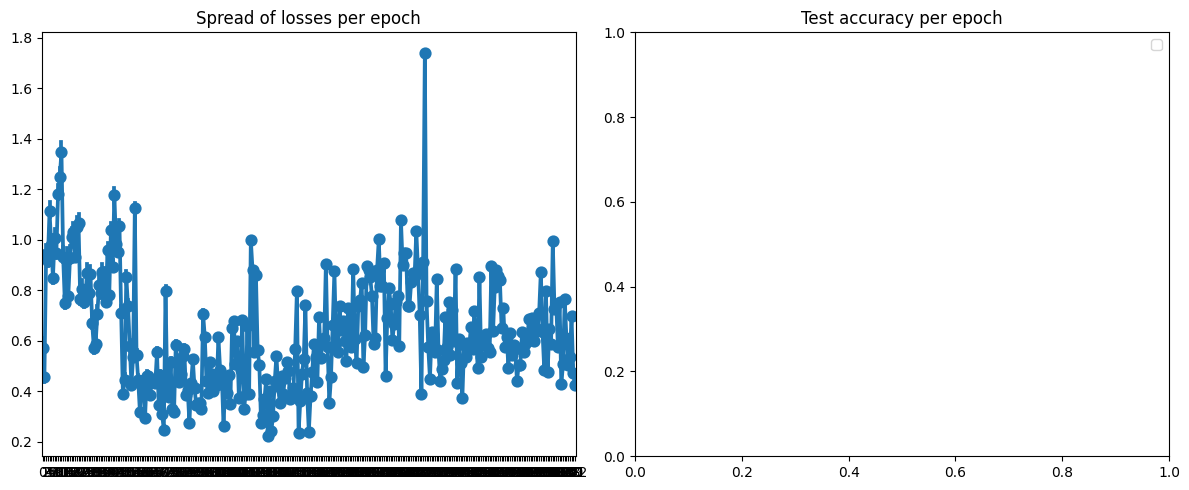

Starting generation with the word: '34' (index: 3230)


In [36]:
from IPython.display import clear_output
# from multiprocessing import Process, Queue
from threading import Thread
import time
num_epochs = 500
batch_size = 32
hidden_dim = 256
rngs = nnx.Rngs(0)
weight_decay = 1e-4
learning_rate = 2e-4

model = LSTMTextGenerator(vocab_size=vocab_size, embedding_dim=embedding_dim, hidden_dim=hidden_dim, rngs=rngs)
print(f"Model initialized with vocab_size={vocab_size}, embedding_dim={embedding_dim}, hidden_dim={hidden_dim}")
optax_ = optax.chain(optax.add_decayed_weights(weight_decay), optax.adam(learning_rate=learning_rate))
optimizer= nnx.Optimizer(model, optax_)
# losses, accuracies = trainer(model=model, optimizer=optimizer, X_Train=X_Train, 
#         X_test=X_test, Y_Train=Y_Train, Y_test=Y_test, 
#        batch_size=batch_size, num_epochs=num_epochs)

losses, accuracies = [], []

model_process = Thread(target = trainer, args=(num_epochs, X_Train, Y_Train, X_test, Y_test, model, optimizer, batch_size, losses, accuracies))
model_process.start()

while model_process.is_alive():
    time.sleep(5)
    clear_output(wait=False)
    if not model_process.is_alive():
        try:
            plot_losses(losses, accuracies, num_epochs)
            tester(model, text_in=['34', 'why', 'Why'], seq_len=30)
        except:
            pass

        break
        

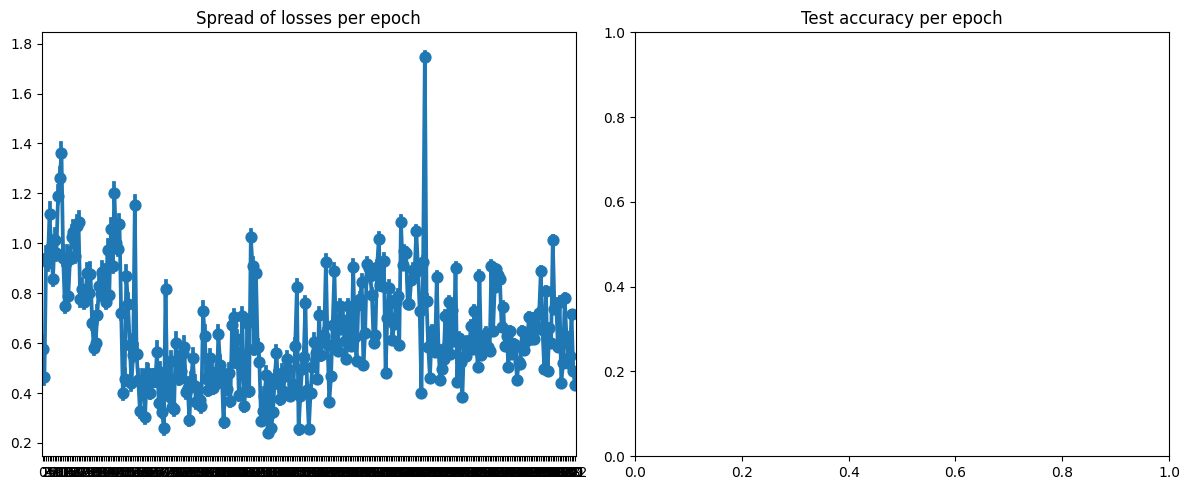

Starting generation with the word: '34' (index: 3230)

Generated Text Sequence:
34                                                            
Starting generation with the word: 'why' (index: 4724)

Generated Text Sequence:
why   I n't continue a grounds of my could be a day )                                  
Starting generation with the word: 'Why' (index: 4803)

Generated Text Sequence:
Why   I n't continue a grounds to my made on your day .                                  


In [42]:
plot_losses(losses_wo_emb, accuracies_wo_emb, num_epochs)
tester(model_wo_emb, text_in=['34', 'why', 'Why'], seq_len=30)

Text(0.5, 1.0, 'Avg accuracy per epoch')

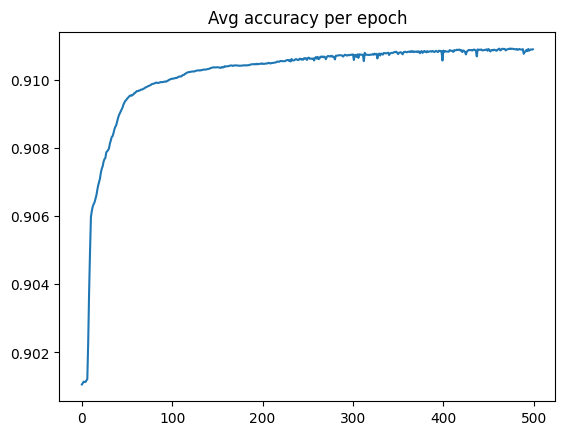

In [56]:
# sns.lineplot(pd.DataFrame(accuracies_wo_emb)[0])
plt.plot(range(500), pd.DataFrame(accuracies_wo_emb))
plt.title("Avg accuracy per epoch")
# pd.DataFrame(accuracies_wo_emb)[0]

## Conclusion
1. LSTM can be called as a more complex probabilistic next word predictor.
2. Cannot make corelations between different parts of the sentence.
3. A balance between memorization and generalization hard to maintain in a small network. (Speculation)

In [ ]:
#mean losses in lstm text generator
print(pd.DataFrame(losses).sum()/losses.__len__(), "is the required loss, ", pd.DataFrame(accuracies).sum()/accuracies.__len__(), " is the required accuracy of LSTMTextGenerator")
#mean losses in lstm wo emb
print(pd.DataFrame(losses_wo_emb).sum()/losses_wo_emb.__len__(), "is the required loss, ", pd.DataFrame(accuracies_wo_emb).sum()/accuracies.__len__(), " is the required accuracy of LSTM_wo_emb")

In [ ]:
pd.DataFrame(accuracies).sum()/accuracies.__len__()

In [ ]:
m = pd.DataFrame(accuracies_wo_emb)
m[0].mean()

In [ ]:
pd.DataFrame(losses).mean().mean()

In [ ]:
pd.DataFrame(losses_wo_emb).mean().mean()

In [ ]:
pd.DataFrame(accuracies)[0].mean()

## Testing the accuracies of the model using BLEU and ROUGE natural language geenration test to compare the models.

In [89]:
import evaluate
import numpy as np

# 1. Load the metrics
# BLEU is generally used for translation; ROUGE is for summarization/general generation
bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")

def evaluate_model(predictions, references):
    """
    Args:
        predictions: List of strings (generated by your LSTM)
        references: List of lists of strings (each prediction can have multiple ground truths)
                    e.g., [["the cat sat"], ["a dog barked"]]
    """
    
    # BLEU Score
    # Note: 'references' for BLEU usually expects a list of lists 
    # because one prediction can be compared against multiple correct answers.
    bleu_results = bleu_metric.compute(predictions=predictions, references=references)
    
    # ROUGE Score
    # ROUGE typically compares 1-to-1 strings for summarization tasks.
    # Flattening references for ROUGE if they are in list-of-lists format
    rouge_refs = [ref[0] if isinstance(ref, list) else ref for ref in references]
    rouge_results = rouge_metric.compute(predictions=predictions, references=rouge_refs)
    
    return {
        "BLEU": bleu_results['bleu'],
        "ROUGE-1": rouge_results['rouge1'],
        "ROUGE-2": rouge_results['rouge2'],
        "ROUGE-L": rouge_results['rougeL']
    }

# --- Example Usage ---
# Suppose your LSTM generated these:
generated_texts = [
    # "the cat is on the mat", 
    # "there is a dog in the park"
    "The luna is the continue a grounds of Moslem could be a day ) .",
    
]

# The actual human-written labels:
ground_truth = [
    # ["the cat is sitting on the mat", "a cat is on the mat"], # Multiple refs allowed
    # ["a dog is playing in the park"]
    # ["Al-Zaman : American forces killed Shaikh Abdullah al-Ani, the preacher at the mosque in the town of Qaim, near the Syrian border."],
    ["The MoI in Iraq is equivalent to the US FBI, so this would be like having J. Edgar Hoover unwittingly employ at a high level members of the Weathermen bombers back in the 1960s."],
]

results = evaluate_model(generated_texts, ground_truth)

print("--- Model Evaluation Metrics ---")
for metric, score in results.items():
    print(f"{metric}: {score:.4f}")

--- Model Evaluation Metrics ---
BLEU: 0.0000
ROUGE-1: 0.2553
ROUGE-2: 0.0000
ROUGE-L: 0.2128


In [85]:
dataset[4]

TokenList<The, MoI, in, Iraq, is, equivalent, to, the, US, FBI, ,, so, this, would, be, like, having, J., Edgar, Hoover, unwittingly, employ, at, a, high, level, members, of, the, Weathermen, bombers, back, in, the, 1960s, ., metadata={sent_id: "weblog-juancole.com_juancole_20051126063000_ENG_20051126_063000-0005", text: "The MoI in Iraq is equivalent to the US FBI, so this would be like having J. Edgar Hoover unwittingly employ at a high level members of the Weathermen bombers back in the 1960s."}>

In [87]:
tester(model_wo_emb, text_in=['The', 'What'], seq_len=30)

Starting generation with the word: 'The' (index: 66)

Generated Text Sequence:
The luna is the continue a grounds of Moslem could be a day ) .                                
Starting generation with the word: 'What' (index: 576)

Generated Text Sequence:
What   I 's a not be out to my who I can do do n't take .                          


In [78]:
nlp('why').vector

array([ 1.2970675 , -1.1692188 ,  0.40015614, -0.0906357 , -0.66232675,
        0.11488655,  0.42648825, -0.22842008, -0.3662965 , -0.14107275,
       -0.40919614, -0.33116567, -0.2277021 , -1.2513199 , -0.57451403,
       -0.6319745 , -0.07990356, -0.05989803, -0.48603496,  0.6052372 ,
       -1.2302357 ,  1.2286831 , -0.17849189, -0.4457141 ,  1.0778731 ,
        1.9498997 , -1.3557467 ,  1.2279533 ,  0.7181266 ,  0.54626936,
       -0.06519893, -0.67092866, -1.2806034 ,  0.50543416, -1.1855409 ,
        0.06971362, -0.95942175, -0.3170127 , -0.9798975 ,  1.3209517 ,
       -0.18136099, -1.1492488 , -0.32005873, -0.4986465 ,  1.0275338 ,
       -1.0294262 , -1.0389335 , -1.0541303 , -0.6578872 , -0.54456264,
        1.2707121 ,  0.32771   , -0.818352  ,  0.59991705,  0.4477359 ,
        0.09030789,  0.6643962 ,  1.4948257 , -0.19946282,  1.3749017 ,
       -0.42175254, -0.03840932, -0.38762087, -0.9925061 ,  0.72780156,
       -0.34586504,  0.7284443 , -0.71553993,  2.7682648 , -0.02